# ASOS Data Exploration
Starter notebook for loading, inspecting, cleaning, and visualizing the "products_asos" CSV file.

## Business Case and Project Context

### Project Purpose
ASOS offers a large and fast-moving assortment across brands, categories, and price points. This analysis evaluates stock availability and potential revenue risk to support better inventory and replenishment decisions.

### Why this analysis matters
Frequent stockouts can reduce conversion, delay purchases, and shift demand to competitors. By identifying where stock pressure is highest, ASOS can prioritize actions that protect revenue and improve customer experience.

### Stakeholders
- Buying and Merchandising teams
- Inventory Planning and Supply Chain teams
- Commercial and Category Managers
- Finance (OTB / budget allocation)
- Data and Analytics teams

### Key business questions
1. Which brands and SKUs show the highest stockout pressure?
2. Where is potential revenue risk concentrated?
3. Which product-type and price-band segments are most exposed?
4. Which issues require replenishment vs. forecasting/supplier improvements?
5. Is data quality sufficient to trust and operationalize recommendations?

### Working hypotheses
- H1: High-price items with high stockout rates represent the highest commercial risk
- H2: Stockout risk is concentrated in specific product-type and price-band segments
- H3: A small group of brands/SKUs accounts for a disproportionate share of revenue risk
- H4: Data quality issues (unknown brands, invalid prices, duplicates) materially affect ranking quality and must be monitored

### Decision objective
Translate analysis into concrete actions (replenish, review forecast/supplier, maintain, monitor) to reduce stockout risk and improve availability in priority segments.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

### 1) Load data

In [ ]:
# on_bad_lines='skip': Rows with malformed CSV structure are skipped during load; 
# results are based on successfully parsed rows only

df = pd.read_csv('../products_asos.csv', on_bad_lines='skip')
df.head()

,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
# Optional: normalize color labels if color-level analysis is needed
# df["color"] = df["color"].astype(str).str.strip().str.title()

### 2) Initial Data Understanding

In [4]:
print('Shape:', df.shape)
df.info()

Shape: (30845, 9)
<class 'pandas.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  str    
 1   name         30827 non-null  str    
 2   size         30827 non-null  str    
 3   category     30827 non-null  str    
 4   price        30827 non-null  str    
 5   color        30827 non-null  str    
 6   sku          30827 non-null  float64
 7   description  30827 non-null  str    
 8   images       30827 non-null  str    
dtypes: float64(1), str(8)
memory usage: 2.1 MB


In [ ]:
# Shows summary statistics for all columns (numeric and non-numeric), 
# transposes the result for readability, and displays only the first 20 rows

df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
url,30827,30468,https://www.asos.com/nike-running/nike-running...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,30827,29493,ASOS 4505 icon performance t-shirt,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,30827,5073,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14,UK 16,UK 18",2912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,30827,29492,ASOS 4505 icon performance t-shirt,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,30827,880,30.00,706,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,30827,3636,BLACK,3289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,30827.0,NaN,NaN,NaN,115497632.305609,22593355.267486,401020.0,117346850.0,119923352.0,122872647.5,129261550.0
description,30827,29971,[{'Product Details': 'Coats & Jackets by Collu...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
images,30827,29972,['https://images.asos-media.com/products/collu...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3) Data Quality and Inspection (Before Cleaning)

In [ ]:
# Missing values overview (all columns)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}))

In [ ]:
# Duplicate checks (row-level and key-level)

print("Duplicate full rows:", df.duplicated().sum())
print("Duplicate url:", df.duplicated(subset=["url"]).sum())
print("Duplicate sku:", df.duplicated(subset=["sku"]).sum())
print("Duplicate name+color:", df.duplicated(subset=["name", "color"]).sum())

In [ ]:
# Data type and value sanity (before conversion)

print(df.dtypes)

print("Nulls in critical columns:")
critical_cols = ["url", "name", "price", "size", "description"]
print(df[critical_cols].isna().sum())

In [ ]:
#  Price field quality check (pre-conversion)

price_num = pd.to_numeric(df["price"], errors="coerce")
print("Non-numeric price rows:", price_num.isna().sum())
print("Share non-numeric price (%):", round(price_num.isna().mean() * 100, 2))

In [ ]:
# Categorical spread (quick cardinality + top values):
# This checks text-type columns (like brand/color) to see how 
# many different values exist and which values appear most often

for col in ["Brand" if "Brand" in df.columns else "category", "color"]:
    if col in df.columns:
        print(f"\n{col} unique values:", df[col].nunique(dropna=True))
        print(df[col].value_counts(dropna=False).head(10))

In [ ]:
# String-length / parsing readiness checks (important for description and size)

print("description length stats:")
print(df["description"].astype(str).str.len().describe())

print("\nsize examples:")
print(df["size"].dropna().astype(str).head(10).to_list())

### 4) Changes to Price column

In [6]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"Data Loaded: {len(df)} rows")
df.head()

Data Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
# Outlier scan after price conversion

print(df["price"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print("Price <= 0 rows:", (df["price"] <= 0).sum())

### 5) Brand Extraction and Standardization

In [37]:
# Extracts the brand name from each description by finding text after 
# “by” and stores it in brand_raw, defaulting to "Unknown" when no brand is found

df["brand_raw"] = (
    df["description"]
    .astype(str)
    .str.extract(r"(?i)\bby\s+([A-Za-z]+)", expand=False)
    .fillna("Unknown")
)


###### Brand extraction uses the first token after “by”, which is consistent but may misclassify some complex brand strings

In [38]:
# Normalize extracted brand tokens and create Brand

df["Brand"] = df["brand_raw"].replace({
    "New": "New Look",
    "River": "River Island",
    "Miss": "Miss Selfridge",
    "TopshopWelcome": "Topshop"
})

# Keep rows with identified brands
df_clean = df[~df["Brand"].isin(["Unknown", "NA"])].copy()

print(df_clean["Brand"].value_counts().head(5))


Brand
ASOS              4844
Topshop           1018
New Look           511
River Island       474
Miss Selfridge     429
Name: count, dtype: int64


### 6) Understanding the Inventory stock Management 

In [ ]:
# If we look at the "size" column, we see sizes like 4, UK or 10 UK but
# also "Out of stock".

# Analyze stockouts from size availability string

def calculate_stockout_metrics(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0

    sizes = [s.strip() for s in size_str.split(",") if s.strip()]
    total_sizes = len(sizes)

    out_of_stock_count = size_str.count("Out of stock")
    stockout_rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, stockout_rate

metrics = df_clean["size"].apply(calculate_stockout_metrics)

df_clean["Stockout_Count"] = [m[0] for m in metrics]
df_clean["Stockout_Rate"] = [m[1] for m in metrics]

# Canonical KPI used throughout notebook ( one main metric is used consistently.Here: Revenue_Risk_Score)
df_clean["Revenue_Risk_Score"] = df_clean["price"] * df_clean["Stockout_Count"]

cols = ["Brand", "name", "price", "Stockout_Count", "Stockout_Rate", "Revenue_Risk_Score"]
print(df_clean.sort_values(by="Revenue_Risk_Score", ascending=False).head(5)[cols])
    

                  Brand                                               name  \
2941            Barbour               Barbour Beadnell wax jacket in black   
2679   BarbourExclusive  Barbour x ASOS exclusive Stephanie wax parka i...   
3192       AllSaintsMid      AllSaints Elora leather biker jacket in black   
21948           Topshop  Topshop premium real leather collared zip thro...   
2715               ASOS  ASOS DESIGN premium real leather trench coat i...   

       price  Stockout_Count  Stockout_Rate  Revenue_Risk_Score  
2941   219.0               9       0.900000              1971.0  
2679   279.0               7       0.875000              1953.0  
3192   319.0               6       0.857143              1914.0  
21948  260.0               7       0.875000              1820.0  
2715   220.0               7       0.875000              1540.0  


### 7) KPI and Action Framework

In [43]:
# -----------------------------
# 1) KPI naming consistency
# -----------------------------
# Revenue_Risk_Score is already created in Section 5.
# Keep this cell as a checkpoint to confirm the KPI exists.
assert "Revenue_Risk_Score" in df_clean.columns, "Revenue_Risk_Score is missing. Run Section 5 first."
print("KPI check passed: Revenue_Risk_Score is available.")

KPI check passed: Revenue_Risk_Score is available.


In [40]:
# -----------------------------------------
# 2) Top-10 action tables (Brand + SKU level)
# -----------------------------------------

brand_actions = (
    df_clean.groupby("Brand", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        avg_stockout_rate=("Stockout_Rate", "mean"),
        item_count=("name", "count"),
        Revenue_Risk_Score=("Revenue_Risk_Score", "sum")
    )
    .assign(
        avg_price=lambda x: x["avg_price"].round(2),
        avg_stockout_rate=lambda x: x["avg_stockout_rate"].round(3),
        Revenue_Risk_Score=lambda x: x["Revenue_Risk_Score"].round(2)
    )
    .sort_values("Revenue_Risk_Score", ascending=False)
    .head(10)
)

sku_actions = (
    df_clean.groupby(["sku", "Brand", "name"], as_index=False)
    .agg(
        avg_price=("price", "mean"),
        avg_stockout_rate=("Stockout_Rate", "mean"),
        item_count=("name", "count"),
        Revenue_Risk_Score=("Revenue_Risk_Score", "sum")
    )
    .assign(
        avg_price=lambda x: x["avg_price"].round(2),
        avg_stockout_rate=lambda x: x["avg_stockout_rate"].round(3),
        Revenue_Risk_Score=lambda x: x["Revenue_Risk_Score"].round(2)
    )
    .sort_values("Revenue_Risk_Score", ascending=False)
    .head(10)
)

print("Top 10 Brands by Revenue_Risk_Score")
display(brand_actions)

print("Top 10 SKUs by Revenue_Risk_Score")
display(sku_actions)

Top 10 Brands by Revenue_Risk_Score


,Brand,avg_price,avg_stockout_rate,item_count,Revenue_Risk_Score
19,ASOS,46.57,0.279,4844,471999.00
1170,Topshop,47.77,0.251,1018,76133.00
1041,River Island,45.30,0.303,474,40083.00
795,New Look,29.21,0.409,511,39671.77
1165,The,80.42,0.228,303,27545.00
1402,adidas,48.34,0.226,384,27508.00
668,Miss Selfridge,36.48,0.255,429,27406.04
1236,Vero,34.86,0.324,327,22179.00
980,Pull,29.25,0.388,268,14737.62
1020,Reclaimed,34.82,0.411,150,14245.65


Top 10 SKUs by Revenue_Risk_Score


,sku,Brand,name,avg_price,avg_stockout_rate,item_count,Revenue_Risk_Score
23,1133360.0,Barbour,Barbour Beadnell wax jacket in black,219.0,0.900,1,1971.0
7270,120539564.0,BarbourExclusive,Barbour x ASOS exclusive Stephanie wax parka i...,279.0,0.875,1,1953.0
6074,119616120.0,AllSaintsMid,AllSaints Elora leather biker jacket in black,319.0,0.857,1,1914.0
12702,123501085.0,Topshop,Topshop premium real leather collared zip thro...,260.0,0.875,1,1820.0
1884,115982793.0,ASOS,ASOS DESIGN Petite smart dad coat in black,75.0,0.750,4,1800.0
2473,116763423.0,ASOS,ASOS DESIGN premium real leather trench coat i...,220.0,0.875,1,1540.0
1845,115955116.0,ASOS,ASOS EDITION geo embellished fringe plunge mid...,250.0,0.750,1,1500.0
4742,119078418.0,Topshop,Topshop Baggy co-ord jeans in green cord,50.0,0.931,1,1350.0
1006,113469223.0,Curvy,Curvy Kate Boost Me Up padded push up bra in b...,30.0,0.611,1,1320.0
24,1219559.0,Barbour,Barbour Beadnell wax jacket in navy,219.0,0.857,1,1314.0


###### `avg_stockout_rate` is the average share of unavailable sizes per item (e.g., 0.30 means ~30% of listed sizes are out of stock on average).  
###### `Revenue_Risk_Score` is a prioritization proxy (`price × stockout_count`, summed), showing where potential revenue risk is highest; it is not actual lost sales.

In [35]:
# ---------------------------------------------------
# 3) Segment by product type (from name) + price band
# ---------------------------------------------------
name_lower = df_clean["name"].astype(str).str.lower()

conditions = [
    name_lower.str.contains(r"coat|jacket|blazer|parka|trench|puffer|gilet|shacket|bomber", regex=True),
    name_lower.str.contains(r"dress", regex=True),
    name_lower.str.contains(r"t-shirt|top|shirt|blouse|bodysuit|vest", regex=True),
    name_lower.str.contains(r"jean|trouser|pant|skirt|short|legging", regex=True),
    name_lower.str.contains(r"jumper|cardigan|knit|sweater", regex=True),
]
choices = ["Outerwear", "Dresses", "Tops", "Bottoms", "Knitwear"]

df_clean["product_type"] = np.select(conditions, choices, default="Other")

df_clean["price_band"] = pd.cut(
    df_clean["price"],
    bins=[0, 20, 40, 60, 100, np.inf],
    labels=["0-20", "20-40", "40-60", "60-100", "100+"],
    include_lowest=True
)

segment_summary = (
    df_clean.groupby(["product_type", "price_band"], as_index=False, observed=True)
    .agg(
        item_count=("name", "count"),
        avg_stockout_rate=("Stockout_Rate", "mean"),
        Revenue_Risk_Score=("Revenue_Risk_Score", "sum")
    )
    .sort_values("Revenue_Risk_Score", ascending=False)
)

display(segment_summary.head(20))


,product_type,price_band,item_count,avg_stockout_rate,Revenue_Risk_Score
6,Dresses,20-40,2987,0.268067,175432.41
7,Dresses,40-60,1985,0.231667,161918.16
8,Dresses,60-100,1493,0.190517,150298.59
26,Tops,20-40,2461,0.294047,137202.94
9,Dresses,100+,707,0.174774,122664.93
23,Outerwear,60-100,720,0.234041,88789.19
24,Outerwear,100+,336,0.222470,73877.24
25,Tops,0-20,1767,0.329711,60749.90
22,Outerwear,40-60,674,0.257239,60461.33
1,Bottoms,20-40,833,0.292166,56177.60


###### This table shows where stockout risk concentrates across product types and price bands.  
###### - `item_count`: how many items are in each segment (segment size).  
###### - `avg_stockout_rate`: average stock pressure in that segment.  
###### - `Revenue_Risk_Score`: combined monetary risk signal for prioritization.  

###### Interpretation: segments with both high `avg_stockout_rate` and high `Revenue_Risk_Score` should be prioritized for replenishment and forecasting improvements.

In [44]:
# -----------------------
# 4) Data quality checks
# -----------------------

df_raw = pd.read_csv("../products_asos.csv", on_bad_lines="skip")

# same brand extraction logic on raw data
raw_brand = (
    df_raw["description"].astype(str)
    .str.extract(r"(?i)\bby\s+([A-Za-z]+)", expand=False)
    .fillna("Unknown")
    .replace({
        "New": "New Look",
        "River": "River Island",
        "Miss": "Miss Selfridge",
        "TopshopWelcome": "Topshop"
    })
)

quality_checks = pd.Series({
    "rows_parsed": len(df_raw),
    "rows_dropped_non_numeric_price": pd.to_numeric(df_raw["price"], errors="coerce").isna().sum(),
    "unknown_brand_pct": (raw_brand.eq("Unknown").mean() * 100).round(2),
    "duplicate_url_pct": (df_raw.duplicated(subset=["url"]).mean() * 100).round(2),
})

display(quality_checks.to_frame("value"))

,value
rows_parsed,30845.00
rows_dropped_non_numeric_price,12467.00
unknown_brand_pct,1.48
duplicate_url_pct,1.22


###### - `rows_parsed`: rows successfully parsed after skipping malformed lines.  
###### - `rows_dropped_non_numeric_price`: rows removed because `price` was invalid/missing.  
###### - `unknown_brand_pct`: share of rows where brand extraction failed (`Unknown`).  
###### - `duplicate_url_pct`: share of duplicate product URLs (possible repeated listings/variants).  

###### Why this matters: these checks quantify data reliability before business conclusions.  
###### High dropped/unknown/duplicate rates indicate that brand rankings and risk scores may be biased and should be interpreted with caution.


In [41]:
# ----------------------------------
# 5) Decision rules (for operations)
# ----------------------------------

brand_strategy = (
    df_clean.groupby("Brand", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        avg_stockout_rate=("Stockout_Rate", "mean"),
        item_count=("name", "count"),
        Revenue_Risk_Score=("Revenue_Risk_Score", "sum")
    )
)

brand_strategy = brand_strategy[brand_strategy["item_count"] > 10].copy()

brand_strategy["Action"] = np.select(
    [
        (brand_strategy["avg_price"] > 40) & (brand_strategy["avg_stockout_rate"] > 0.4),
        (brand_strategy["avg_price"] <= 40) & (brand_strategy["avg_stockout_rate"] > 0.4),
        (brand_strategy["avg_price"] > 40) & (brand_strategy["avg_stockout_rate"] <= 0.4),
    ],
    [
        "Replenishment priority",
        "Supplier/forecasting review",
        "Maintain policy",
    ],
    default="Monitor"
)

display(
    brand_strategy
    .assign(
        avg_price=lambda x: x["avg_price"].round(2),
        avg_stockout_rate=lambda x: x["avg_stockout_rate"].round(3),
        Revenue_Risk_Score=lambda x: x["Revenue_Risk_Score"].round(2)
    )
    .sort_values("Revenue_Risk_Score", ascending=False)
    .head(20)
)


,Brand,avg_price,avg_stockout_rate,item_count,Revenue_Risk_Score,Action
19,ASOS,46.57,0.279,4844,471999.00,Maintain policy
1170,Topshop,47.77,0.251,1018,76133.00,Maintain policy
1041,River Island,45.30,0.303,474,40083.00,Maintain policy
795,New Look,29.21,0.409,511,39671.77,Supplier/forecasting review
1165,The,80.42,0.228,303,27545.00,Maintain policy
1402,adidas,48.34,0.226,384,27508.00,Maintain policy
668,Miss Selfridge,36.48,0.255,429,27406.04,Monitor
1236,Vero,34.86,0.324,327,22179.00,Monitor
980,Pull,29.25,0.388,268,14737.62,Monitor
1020,Reclaimed,34.82,0.411,150,14245.65,Supplier/forecasting review


###### The `Action` column translates metrics into operational priorities:  
###### - `Replenishment priority`: high-price brands with high stockout risk (largest commercial downside).  
###### - `Supplier/forecasting review`: lower-price but high stockout brands (planning/supply issue).  
###### - `Maintain policy`: higher-price brands with controlled stockouts (current approach works).  
###### - `Monitor`: no immediate intervention, continue tracking.

###### This turns analysis into an actionable workflow for buying, merchandising, and inventory teams.

### 8) Final Recommendations and Visualization

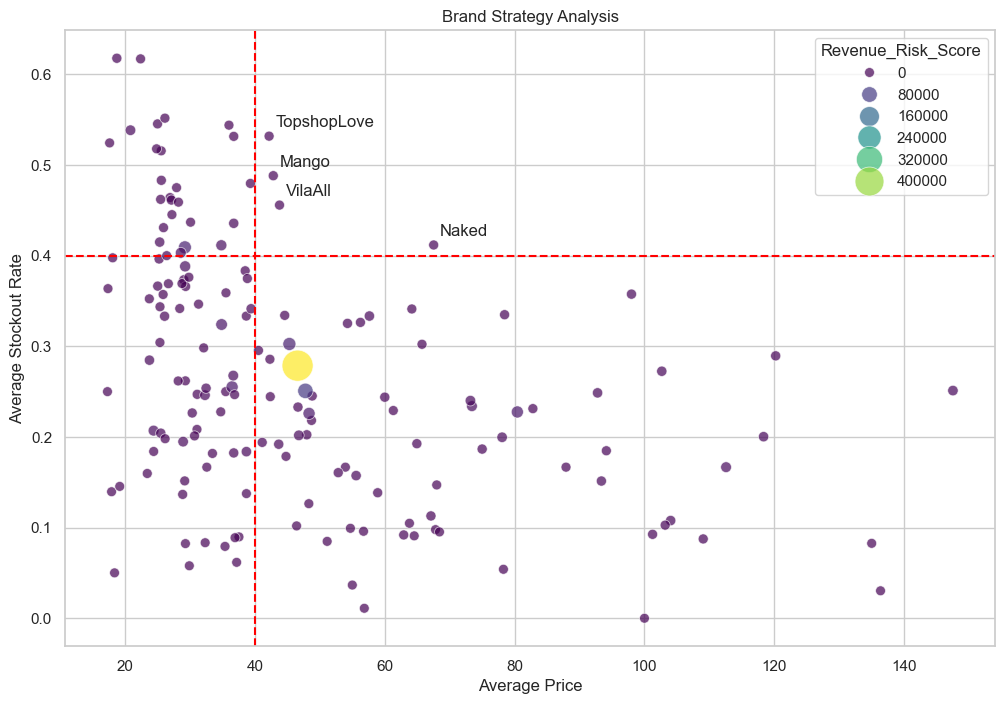

In [42]:
# Reuse decision-rules output for plotting to keep logic consistent
plot_df = brand_strategy.copy()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_df,
    x="avg_price",
    y="avg_stockout_rate",
    size="Revenue_Risk_Score",
    hue="Revenue_Risk_Score",
    palette="viridis",
    sizes=(50, 500),
    alpha=0.7
)

winners = plot_df[
    (plot_df["avg_price"] > 40) &
    (plot_df["avg_stockout_rate"] > 0.4)
]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]["avg_price"] + 1,
        winners.iloc[i]["avg_stockout_rate"] + 0.01,
        winners.iloc[i]["Brand"]
    )

plt.title("Brand Strategy Analysis")
plt.xlabel("Average Price")
plt.ylabel("Average Stockout Rate")
plt.axvline(x=40, color="red", linestyle="--")
plt.axhline(y=0.4, color="red", linestyle="--")
plt.show()


##### What This Analysis Means for Stakeholders:
   This analysis provides an action framework to reduce stockout risk and protect commercial performance.

1. **Replenish Highest-Risk Brands and SKUs Immediately**  
Use the Top-10 `Revenue_Risk_Score` tables as a weekly priority list.  
**Owners:** Buying, Inventory Planning  
**Action:** Increase reorder quantities for items with high `avg_price` and high `avg_stockout_rate`.

2. **Resolve Persistent Stockout Root Causes**  
For items tagged `Supplier/forecasting review`, investigate operational drivers such as lead time, MOQ, delivery delays, and forecast bias.  
**Owners:** Supply Chain, Planning  
**Action:** Adjust forecast inputs and supplier allocation in the next buying cycle.

3. **Allocate Budget by Segment, Not Brand Alone**  
Use `segment_summary` to direct spend toward product-type and price-band combinations with highest risk-adjusted impact.  
**Owners:** Finance, Buying  
**Action:** Ring-fence OTB/replenishment budget for high-risk segments.

4. **Apply Data-Quality Gates Before Decisions**  
Monitor `unknown_brand_pct`, `rows_dropped_non_numeric_price`, and `duplicate_url_pct` in every run.  
**Owners:** Data, Analytics  
**Action:** Enforce quality thresholds (e.g., unknown brands <5%) before publishing recommendations.

5. **Run a Weekly KPI Execution Cadence**  
Track `Revenue_Risk_Score`, `avg_stockout_rate`, Top-10 at-risk SKUs, and action status.  
**Owners:** Analytics, Commercial Leads  
**Action:** Hold a weekly review, assign owners, and close actions with deadlines.

6. **Measure Impact and Continuously Improve**  
Compare pre/post results by brand and segment after actions are implemented.  
**Success metrics:** Lower `avg_stockout_rate`, reduced concentration of risk, and improved availability in priority segments. 



### 9) Limitations and Next Data Needed

##### Current limitations
- This dataset is a static snapshot, so we cannot analyze stockout trends over time
- `Revenue_Risk_Score` is a prioritization proxy (`price × stockout_count`), not actual lost sales
- Brand extraction is rule-based (first token after “by”), so some complex brand strings may be misclassified
- Some rows are skipped during load (`on_bad_lines='skip'`), and data quality can affect ranking precision

##### Next data needed to improve decision quality
1. **Time-series inventory snapshots** (daily/weekly stock by SKU and size)  
   So we can measure stockout duration and trend changes
2. **Sales transactions (units sold, revenue, conversion)**  
   To estimate real lost-sales impact instead of using a proxy
3. **Supplier performance data** (lead times, fill rates, late deliveries, MOQ)  
   To link stockouts to operational root causes and improve forecasting
4. **Promotion/markdown calendar**  
   To separate demand spikes caused by campaigns from structural stock issues
5. **Returns data by brand/SKU/category**  
   To avoid over-replenishing items with high return risk

##### Practical next step
- Build a weekly monitoring pipeline that combines these data sources and updates action priorities (`Replenishment priority`, `Supplier/forecasting review`, `Maintain policy`, `Monitor`) automatically
